# USE CASE 1: Disaster Risk Financing and Budget Allocation

## For: Ministers of Finance, Economic Planning, and Budget Offices

### Key Questions This Analysis Answers:
1. **How much should we budget for disaster response and recovery?**
2. **Which areas need the most financial resources?**
3. **What is the economic justification for DRR investments?**
4. **How can we access international climate finance?**
5. **What are the trends in disaster-related economic losses?**

### Why Complete Data Matters:
- **Without GDP data:** Can only report raw losses (e.g., $10 million)
- **With GDP data:** Can show losses as % of GDP (e.g., 0.5% of GDP) - required for climate finance applications
- **Impact:** Access to Green Climate Fund, Adaptation Fund, and other international financing

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from config import PROCESSED_DATA_DIR, FIGURES_DIR, REPORTS_DIR

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

print("✓ Libraries loaded")

✓ Libraries loaded


## 1. Load Data with Economic Indicators

In [2]:
data_file = PROCESSED_DATA_DIR / 'disaster_events_sendai.csv'

if data_file.exists():
    df = pd.read_csv(data_file)
    print(f"Loaded {len(df)} disaster events")
    
    economic_data_available = df['usdvalue'].notna().sum()
    gdp_data_available = df['gdp'].notna().sum()
    
    print(f"\nEconomic data availability:")
    print(f"  Events with loss data: {economic_data_available} ({economic_data_available/len(df)*100:.1f}%)")
    print(f"  Events with GDP data: {gdp_data_available} ({gdp_data_available/len(df)*100:.1f}%)")
else:
    print("Please run notebook 05_risk_modeling.ipynb first to generate Sendai indicators")
    df = None

Loaded 30 disaster events

Economic data availability:
  Events with loss data: 30 (100.0%)
  Events with GDP data: 30 (100.0%)


## 2. Total Economic Losses Over Time

### Ministerial Message:
"This shows the financial burden disasters place on our economy annually."

ECONOMIC IMPACT SUMMARY

Total economic losses (2010-2023): $0.25 billion USD
Average annual loss: $17.96 million USD
Maximum annual loss: $113.52 million USD (in 2016)


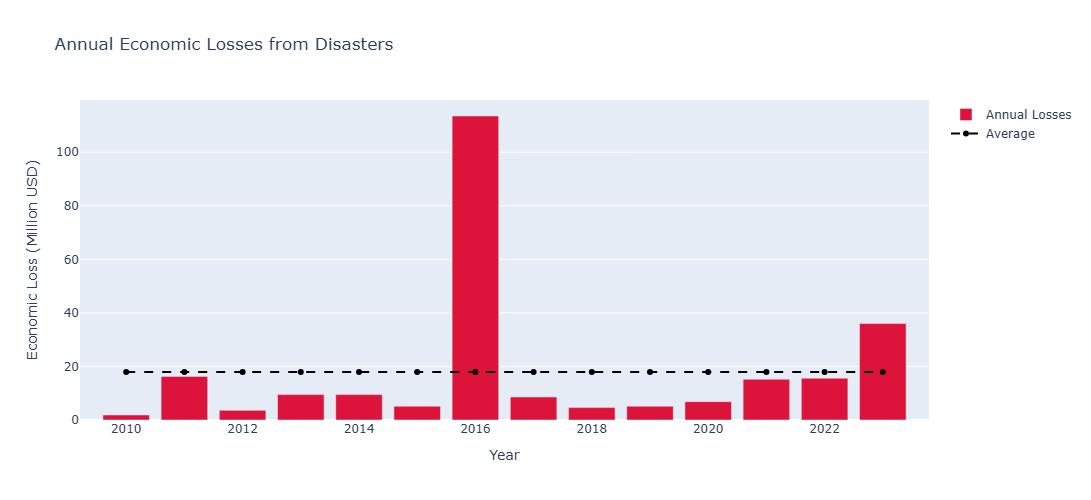

In [3]:
if df is not None and 'usdvalue' in df.columns:
    annual_losses = df.groupby('year')['usdvalue'].sum().reset_index()
    annual_losses['usdvalue_millions'] = annual_losses['usdvalue'] / 1e6
    
    total_losses = df['usdvalue'].sum()
    avg_annual_loss = annual_losses['usdvalue'].mean()
    
    print("="*80)
    print("ECONOMIC IMPACT SUMMARY")
    print("="*80)
    print(f"\nTotal economic losses ({df['year'].min()}-{df['year'].max()}): ${total_losses/1e9:.2f} billion USD")
    print(f"Average annual loss: ${avg_annual_loss/1e6:.2f} million USD")
    print(f"Maximum annual loss: ${annual_losses['usdvalue'].max()/1e6:.2f} million USD (in {annual_losses.loc[annual_losses['usdvalue'].idxmax(), 'year']})")
    
    fig = go.Figure()
    
    fig.add_trace(go.Bar(
        x=annual_losses['year'],
        y=annual_losses['usdvalue_millions'],
        name='Annual Losses',
        marker_color='crimson'
    ))
    
    fig.add_trace(go.Scatter(
        x=annual_losses['year'],
        y=[avg_annual_loss/1e6] * len(annual_losses),
        name='Average',
        line=dict(color='black', dash='dash', width=2)
    ))
    
    fig.update_layout(
        title='Annual Economic Losses from Disasters',
        xaxis_title='Year',
        yaxis_title='Economic Loss (Million USD)',
        hovermode='x unified',
        height=500
    )
    
    fig.show()
    fig.write_html(FIGURES_DIR / 'UC1_annual_economic_losses.html')

## 3. Economic Losses as % of GDP (Sendai Indicator C-1)

### Why This Matters:
- **International Standard:** Required for climate finance applications
- **Fair Comparison:** A $10M loss means different things to different economies
- **Budget Planning:** Shows relative economic burden, not just absolute numbers


ECONOMIC LOSSES AS % OF GDP (Sendai Framework Indicator C-1)

Average annual loss: 0.171% of GDP
Maximum annual loss: 1.638% of GDP

💡 MINISTERIAL INSIGHT:
   Disasters cost us 0.17% of GDP annually.
   Even small DRR investments can yield high returns.


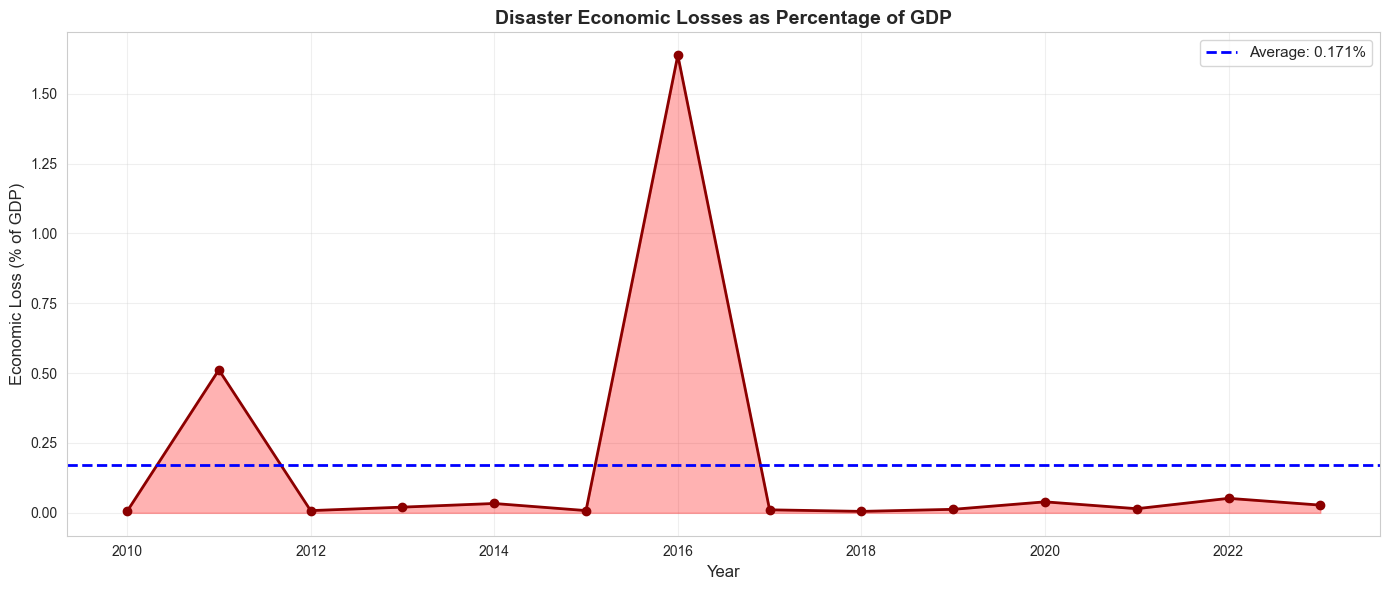

In [4]:
if df is not None and 'sendai_c1_economic_loss_pct_gdp' in df.columns:
    annual_loss_pct = df.groupby('year')['sendai_c1_economic_loss_pct_gdp'].sum().reset_index()
    
    avg_loss_pct = annual_loss_pct['sendai_c1_economic_loss_pct_gdp'].mean()
    max_loss_pct = annual_loss_pct['sendai_c1_economic_loss_pct_gdp'].max()
    
    print("\n" + "="*80)
    print("ECONOMIC LOSSES AS % OF GDP (Sendai Framework Indicator C-1)")
    print("="*80)
    print(f"\nAverage annual loss: {avg_loss_pct:.3f}% of GDP")
    print(f"Maximum annual loss: {max_loss_pct:.3f}% of GDP")
    
    print("\n💡 MINISTERIAL INSIGHT:")
    if avg_loss_pct > 1.0:
        print(f"   Disasters cost us over {avg_loss_pct:.1f}% of GDP annually.")
        print("   This justifies significant DRR investment (typically 1-5% of disaster costs).")
    else:
        print(f"   Disasters cost us {avg_loss_pct:.2f}% of GDP annually.")
        print("   Even small DRR investments can yield high returns.")
    
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(annual_loss_pct['year'], annual_loss_pct['sendai_c1_economic_loss_pct_gdp'],
            marker='o', linewidth=2, markersize=6, color='darkred')
    ax.axhline(avg_loss_pct, color='blue', linestyle='--', linewidth=2,
               label=f'Average: {avg_loss_pct:.3f}%')
    ax.fill_between(annual_loss_pct['year'], 0, annual_loss_pct['sendai_c1_economic_loss_pct_gdp'],
                     alpha=0.3, color='red')
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Economic Loss (% of GDP)', fontsize=12)
    ax.set_title('Disaster Economic Losses as Percentage of GDP', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'UC1_loss_pct_gdp.png', dpi=300, bbox_inches='tight')
    plt.show()

## 4. Cost-Benefit Analysis of DRR Investments

### Investment Justification:
Research shows that every $1 invested in DRR saves $4-7 in disaster losses.


COST-BENEFIT ANALYSIS: DRR INVESTMENT SCENARIOS

Based on average annual loss of $17.96 million USD

Conservative (1% of losses):
  Annual investment: $0.18 million USD
  Expected benefits: $0.72 - $1.26 million USD
  Net benefit: $0.54 - $1.08 million USD
  Return on investment: 4:1 to 7:1

Moderate (3% of losses):
  Annual investment: $0.54 million USD
  Expected benefits: $2.15 - $3.77 million USD
  Net benefit: $1.62 - $3.23 million USD
  Return on investment: 4:1 to 7:1

Ambitious (5% of losses):
  Annual investment: $0.90 million USD
  Expected benefits: $3.59 - $6.28 million USD
  Net benefit: $2.69 - $5.39 million USD
  Return on investment: 4:1 to 7:1



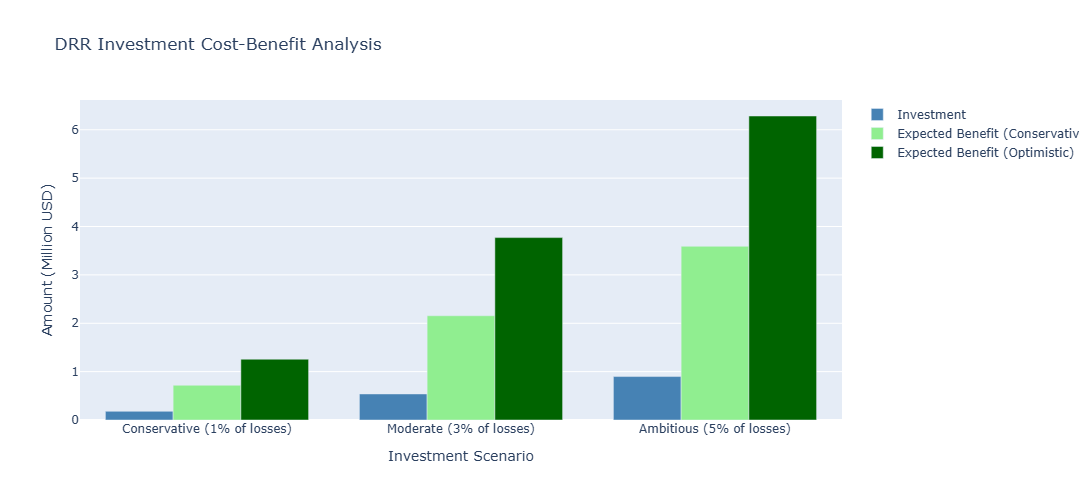

In [5]:
if df is not None and 'usdvalue' in df.columns:
    avg_annual_loss = df.groupby('year')['usdvalue'].sum().mean()
    
    drr_investment_scenarios = {
        'Conservative (1% of losses)': avg_annual_loss * 0.01,
        'Moderate (3% of losses)': avg_annual_loss * 0.03,
        'Ambitious (5% of losses)': avg_annual_loss * 0.05
    }
    
    benefit_ratio_low = 4
    benefit_ratio_high = 7
    
    print("\n" + "="*80)
    print("COST-BENEFIT ANALYSIS: DRR INVESTMENT SCENARIOS")
    print("="*80)
    print(f"\nBased on average annual loss of ${avg_annual_loss/1e6:.2f} million USD\n")
    
    results = []
    for scenario, investment in drr_investment_scenarios.items():
        benefit_low = investment * benefit_ratio_low
        benefit_high = investment * benefit_ratio_high
        net_benefit_low = benefit_low - investment
        net_benefit_high = benefit_high - investment
        
        print(f"{scenario}:")
        print(f"  Annual investment: ${investment/1e6:.2f} million USD")
        print(f"  Expected benefits: ${benefit_low/1e6:.2f} - ${benefit_high/1e6:.2f} million USD")
        print(f"  Net benefit: ${net_benefit_low/1e6:.2f} - ${net_benefit_high/1e6:.2f} million USD")
        print(f"  Return on investment: {benefit_ratio_low}:1 to {benefit_ratio_high}:1\n")
        
        results.append({
            'Scenario': scenario,
            'Investment': investment/1e6,
            'Benefit_Low': benefit_low/1e6,
            'Benefit_High': benefit_high/1e6
        })
    
    results_df = pd.DataFrame(results)
    
    fig = go.Figure()
    
    fig.add_trace(go.Bar(
        name='Investment',
        x=results_df['Scenario'],
        y=results_df['Investment'],
        marker_color='steelblue'
    ))
    
    fig.add_trace(go.Bar(
        name='Expected Benefit (Conservative)',
        x=results_df['Scenario'],
        y=results_df['Benefit_Low'],
        marker_color='lightgreen'
    ))
    
    fig.add_trace(go.Bar(
        name='Expected Benefit (Optimistic)',
        x=results_df['Scenario'],
        y=results_df['Benefit_High'],
        marker_color='darkgreen'
    ))
    
    fig.update_layout(
        title='DRR Investment Cost-Benefit Analysis',
        xaxis_title='Investment Scenario',
        yaxis_title='Amount (Million USD)',
        barmode='group',
        height=500
    )
    
    fig.show()
    fig.write_html(FIGURES_DIR / 'UC1_cost_benefit_analysis.html')

## 5. Geographic Prioritization for Financial Resources

In [6]:
if df is not None and 'level2' in df.columns and 'usdvalue' in df.columns:
    location_losses = df.groupby('level2').agg({
        'usdvalue': 'sum',
        'serial': 'count'
    }).rename(columns={'serial': 'event_count', 'usdvalue': 'total_loss'})
    
    location_losses['avg_loss_per_event'] = location_losses['total_loss'] / location_losses['event_count']
    location_losses = location_losses.sort_values('total_loss', ascending=False).head(20)
    
    print("\n" + "="*80)
    print("TOP 20 LOCATIONS BY ECONOMIC LOSSES - BUDGET ALLOCATION PRIORITIES")
    print("="*80)
    print("\nThese areas should receive priority for:")
    print("  - Contingency budget allocation")
    print("  - DRR infrastructure investment")
    print("  - Insurance/risk transfer mechanisms\n")
    
    display(location_losses)
    
    location_losses.to_csv(REPORTS_DIR / 'UC1_financial_priorities.csv')
    print("\n✓ Financial priorities saved to outputs/reports/")


TOP 20 LOCATIONS BY ECONOMIC LOSSES - BUDGET ALLOCATION PRIORITIES

These areas should receive priority for:
  - Contingency budget allocation
  - DRR infrastructure investment
  - Insurance/risk transfer mechanisms



,total_loss,event_count,avg_loss_per_event
level2,,,
Bay,106800000,1,106800000.0
Somali,30000000,1,30000000.0
Nairobi,15108000,3,5036000.0
Western,14940000,2,7470000.0
Lower Shabelle,14400000,1,14400000.0
Rift Valley,10404000,2,5202000.0
Eastern,6840000,2,3420000.0
Nyanza,6720000,1,6720000.0
Northern,6720000,1,6720000.0



✓ Financial priorities saved to outputs/reports/


## 6. Losses by Hazard Type - Sector-Specific Budgeting


Economic Losses by Hazard Type (Top 10):
  DROUGHT: $163.68M (65.1% of total)
  FLOOD: $66.95M (26.6% of total)
  STORM: $13.69M (5.4% of total)
  LANDSLIDE: $2.41M (1.0% of total)
  EARTHQUAKE: $1.44M (0.6% of total)
  FIRE: $1.34M (0.5% of total)
  HEAVY RAIN: $1.07M (0.4% of total)
  EPIDEMIC: $0.80M (0.3% of total)


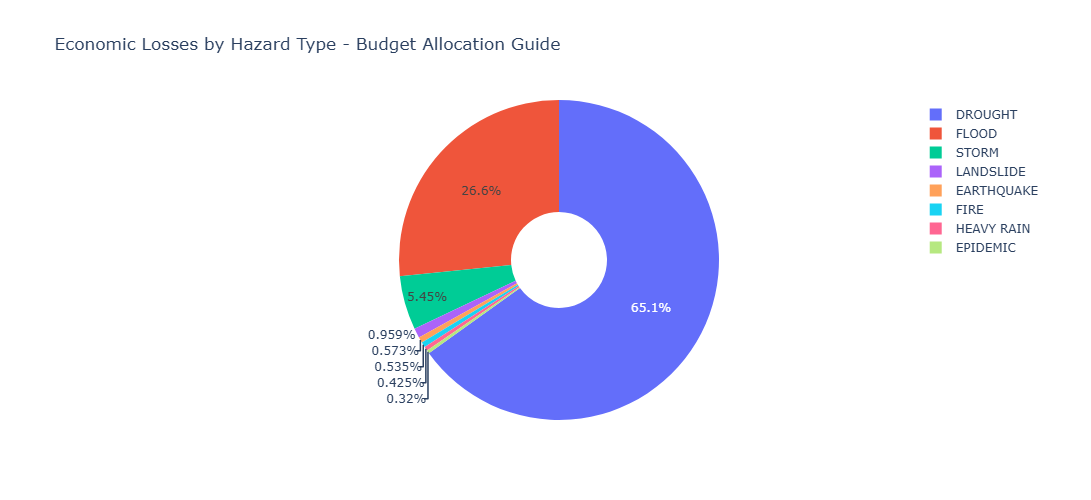

In [7]:
if df is not None and 'hazardtype' in df.columns and 'usdvalue' in df.columns:
    hazard_losses = df.groupby('hazardtype')['usdvalue'].sum().sort_values(ascending=False).head(10)
    
    print("\nEconomic Losses by Hazard Type (Top 10):")
    for hazard, loss in hazard_losses.items():
        pct = (loss / df['usdvalue'].sum()) * 100
        print(f"  {hazard}: ${loss/1e6:.2f}M ({pct:.1f}% of total)")
    
    fig = go.Figure(data=[go.Pie(
        labels=hazard_losses.index,
        values=hazard_losses.values,
        hole=0.3
    )])
    
    fig.update_layout(
        title='Economic Losses by Hazard Type - Budget Allocation Guide',
        height=500
    )
    
    fig.show()
    fig.write_html(FIGURES_DIR / 'UC1_losses_by_hazard.html')

## 7. Climate Finance Application Support

### Data Package for International Funding Applications

In [8]:
if df is not None:
    climate_finance_data = {
        'Total Economic Losses (USD)': df['usdvalue'].sum(),
        'Average Annual Loss (USD)': df.groupby('year')['usdvalue'].sum().mean(),
        'Loss as % of GDP (avg)': df['sendai_c1_economic_loss_pct_gdp'].mean() if 'sendai_c1_economic_loss_pct_gdp' in df.columns else None,
        'People Affected (total)': df['total_affected'].sum() if 'total_affected' in df.columns else None,
        'Deaths (total)': df['total_deaths'].sum() if 'total_deaths' in df.columns else None,
        'Infrastructure Damaged': df[['housesdestroyed', 'housesdamaged', 'educationcenters', 'healthcenters']].sum().sum() if all(col in df.columns for col in ['housesdestroyed', 'housesdamaged']) else None,
        'Time Period': f"{df['year'].min()}-{df['year'].max()}",
        'Number of Events': len(df)
    }
    
    print("\n" + "="*80)
    print("CLIMATE FINANCE APPLICATION DATA PACKAGE")
    print("="*80)
    print("\nUse this data for applications to:")
    print("  - Green Climate Fund (GCF)")
    print("  - Adaptation Fund")
    print("  - Global Environment Facility (GEF)")
    print("  - Bilateral climate finance mechanisms\n")
    
    for key, value in climate_finance_data.items():
        if value is not None:
            if isinstance(value, float) and value > 1000:
                print(f"  {key}: {value:,.0f}")
            elif isinstance(value, float):
                print(f"  {key}: {value:.3f}")
            else:
                print(f"  {key}: {value}")
    
    climate_finance_df = pd.DataFrame([climate_finance_data])
    climate_finance_df.to_csv(REPORTS_DIR / 'UC1_climate_finance_data.csv', index=False)
    print("\n✓ Climate finance data package saved")


CLIMATE FINANCE APPLICATION DATA PACKAGE

Use this data for applications to:
  - Green Climate Fund (GCF)
  - Adaptation Fund
  - Global Environment Facility (GEF)
  - Bilateral climate finance mechanisms

  Total Economic Losses (USD): 251388000
  Average Annual Loss (USD): 17,956,286
  Loss as % of GDP (avg): 0.080
  People Affected (total): 11682109
  Deaths (total): 11887
  Infrastructure Damaged: 672782
  Time Period: 2010-2023
  Number of Events: 30

✓ Climate finance data package saved


## 8. Executive Summary for Ministers

### 2-Page Briefing Note

In [9]:
if df is not None:
    print("\n" + "="*80)
    print("EXECUTIVE BRIEFING: DISASTER RISK FINANCING")
    print("For: Minister of Finance / Economic Planning")
    print("="*80)
    
    total_loss = df['usdvalue'].sum()
    avg_annual = df.groupby('year')['usdvalue'].sum().mean()
    
    print("\n1. THE PROBLEM:")
    print(f"   Disasters have cost our economy ${total_loss/1e9:.2f} billion USD over {df['year'].max() - df['year'].min()} years.")
    print(f"   Average annual loss: ${avg_annual/1e6:.2f} million USD.")
    
    if 'sendai_c1_economic_loss_pct_gdp' in df.columns:
        avg_pct = df['sendai_c1_economic_loss_pct_gdp'].mean()
        print(f"   This represents {avg_pct:.2f}% of our GDP annually.")
    
    print("\n2. THE OPPORTUNITY:")
    moderate_investment = avg_annual * 0.03
    expected_benefit = moderate_investment * 5.5
    print(f"   A moderate DRR investment of ${moderate_investment/1e6:.2f}M annually (3% of losses)")
    print(f"   Could save ${expected_benefit/1e6:.2f}M in avoided losses (5.5:1 return).")
    
    print("\n3. RECOMMENDED ACTIONS:")
    print("   a) Allocate contingency budget based on geographic priorities (see report)")
    print("   b) Invest in DRR infrastructure in high-loss areas")
    print("   c) Apply for international climate finance using this data")
    print("   d) Establish disaster risk financing mechanisms (insurance, reserves)")
    
    print("\n4. DATA ADVANTAGE:")
    print("   ✓ We can now calculate losses as % of GDP (required for climate finance)")
    print("   ✓ We have evidence for budget justification")
    print("   ✓ We can prioritize investments geographically")
    print("   ✓ We meet Sendai Framework reporting requirements")
    
    print("\n" + "="*80)


EXECUTIVE BRIEFING: DISASTER RISK FINANCING
For: Minister of Finance / Economic Planning

1. THE PROBLEM:
   Disasters have cost our economy $0.25 billion USD over 13 years.
   Average annual loss: $17.96 million USD.
   This represents 0.08% of our GDP annually.

2. THE OPPORTUNITY:
   A moderate DRR investment of $0.54M annually (3% of losses)
   Could save $2.96M in avoided losses (5.5:1 return).

3. RECOMMENDED ACTIONS:
   a) Allocate contingency budget based on geographic priorities (see report)
   b) Invest in DRR infrastructure in high-loss areas
   c) Apply for international climate finance using this data
   d) Establish disaster risk financing mechanisms (insurance, reserves)

4. DATA ADVANTAGE:
   ✓ We can now calculate losses as % of GDP (required for climate finance)
   ✓ We have evidence for budget justification
   ✓ We can prioritize investments geographically
   ✓ We meet Sendai Framework reporting requirements



## 7.5 Insurance Premium Calculations Based on Risk

### Risk-Based Insurance Pricing

Using historical loss data to calculate actuarially sound insurance premiums.


INSURANCE PREMIUM CALCULATIONS - RISK-BASED PRICING

Based on 14 years of historical data

Top 20 locations by insurance premium:



,total_loss,avg_loss,std_loss,loss_events,total_events,annual_frequency,expected_annual_loss,pure_premium,risk_loading,admin_costs,total_premium,premium_pct_of_avg_loss,risk_tier
level2,,,,,,,,,,,,,
Bay,106800000,106800000.0,NaN,1,1,0.071429,7.628571e+06,7.628571e+06,1.907143e+06,1.144286e+06,10680000.0,10.0,LOW RISK
Somali,30000000,30000000.0,NaN,1,1,0.071429,2.142857e+06,2.142857e+06,5.357143e+05,3.214286e+05,3000000.0,10.0,LOW RISK
Nairobi,15108000,5036000.0,3.584574e+06,3,3,0.214286,1.079143e+06,1.079143e+06,2.697857e+05,1.618714e+05,1510800.0,30.0,LOW RISK
Western,14940000,7470000.0,9.800500e+06,2,2,0.142857,1.067143e+06,1.067143e+06,2.667857e+05,1.600714e+05,1494000.0,20.0,LOW RISK
Lower Shabelle,14400000,14400000.0,NaN,1,1,0.071429,1.028571e+06,1.028571e+06,2.571429e+05,1.542857e+05,1440000.0,10.0,LOW RISK
Rift Valley,10404000,5202000.0,6.219711e+06,2,2,0.142857,7.431429e+05,7.431429e+05,1.857857e+05,1.114714e+05,1040400.0,20.0,LOW RISK
Eastern,6840000,3420000.0,9.333810e+05,2,2,0.142857,4.885714e+05,4.885714e+05,1.221429e+05,7.328571e+04,684000.0,20.0,LOW RISK
Nyanza,6720000,6720000.0,NaN,1,1,0.071429,4.800000e+05,4.800000e+05,1.200000e+05,7.200000e+04,672000.0,10.0,LOW RISK
Northern,6720000,6720000.0,NaN,1,1,0.071429,4.800000e+05,4.800000e+05,1.200000e+05,7.200000e+04,672000.0,10.0,LOW RISK



PREMIUM TIERS BY RISK LEVEL

LOW RISK (25 locations):
  Average annual frequency: 0.09 events/year
  Average annual premium: $1.01 million USD
  Premium breakdown:
    - Pure premium (expected loss): $0.72M
    - Risk loading (25%): $0.18M
    - Administrative costs (15%): $0.11M


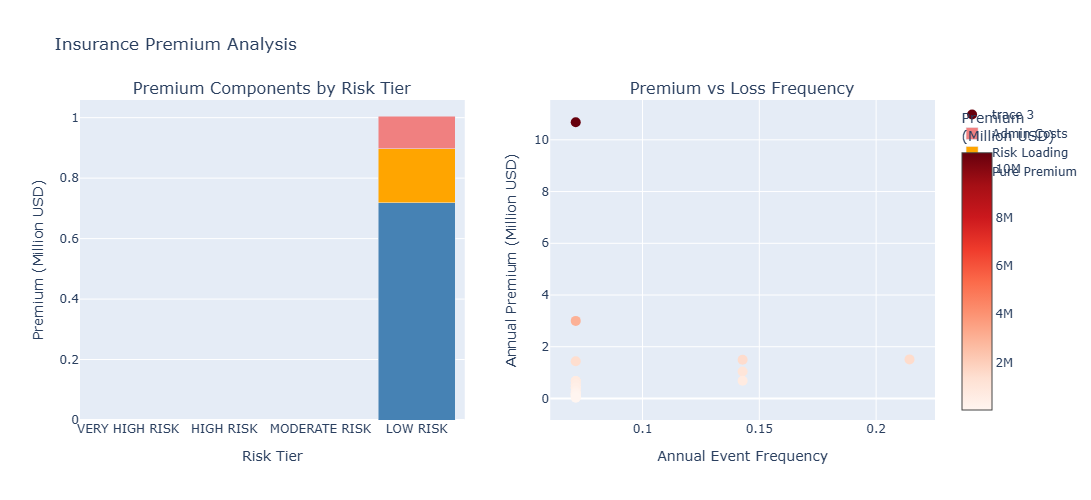


NATIONAL DISASTER INSURANCE POOL REQUIREMENTS

Total annual premium collection: $0.03 billion USD
Expected annual payout: $0.02 billion USD
Risk reserve (25% loading): $0.00 billion USD

💡 INSURANCE POLICY RECOMMENDATIONS:

1. MANDATORY INSURANCE ZONES:

2. SUBSIDIZED INSURANCE:
   For low-income households in high-risk areas:
   → Government subsidizes 50-75% of premium
   → Ensures coverage for vulnerable populations

3. RISK POOLING:
   Establish national disaster insurance pool
   → Annual premium collection: $0.03B
   → Reinsurance for catastrophic events

4. PREMIUM INCENTIVES:
   Reduce premiums for risk reduction measures:
   → 10-20% discount for resilient construction
   → 5-10% discount for early warning system participation

✓ Insurance premium analysis saved to outputs/reports/

EXAMPLE INSURANCE QUOTE

Location: Bay
Risk Tier: LOW RISK

Risk Profile:
  - Historical event frequency: 0.07 events per year
  - Average loss per event: $106.80 million USD
  - Expected annual l

In [10]:
if df is not None and 'level2' in df.columns and 'usdvalue' in df.columns:
    # Calculate insurance premiums based on risk
    from scipy import stats
    
    # Analyze loss patterns by location
    insurance_analysis = df.groupby('level2').agg({
        'usdvalue': ['sum', 'mean', 'std', 'count'],
        'serial': 'count'
    })
    
    insurance_analysis.columns = ['total_loss', 'avg_loss', 'std_loss', 'loss_events', 'total_events']
    
    # Calculate annual frequency
    years_covered = df['year'].max() - df['year'].min() + 1
    insurance_analysis['annual_frequency'] = insurance_analysis['total_events'] / years_covered
    
    # Calculate expected annual loss (EAL)
    insurance_analysis['expected_annual_loss'] = (
        insurance_analysis['annual_frequency'] * insurance_analysis['avg_loss']
    )
    
    # Risk-based premium calculation
    # Premium = Expected Annual Loss + Risk Loading + Administrative Costs
    
    risk_loading_factor = 0.25  # 25% risk loading for uncertainty
    admin_cost_factor = 0.15    # 15% administrative costs
    
    insurance_analysis['pure_premium'] = insurance_analysis['expected_annual_loss']
    insurance_analysis['risk_loading'] = insurance_analysis['pure_premium'] * risk_loading_factor
    insurance_analysis['admin_costs'] = insurance_analysis['pure_premium'] * admin_cost_factor
    insurance_analysis['total_premium'] = (
        insurance_analysis['pure_premium'] + 
        insurance_analysis['risk_loading'] + 
        insurance_analysis['admin_costs']
    )
    
    # Calculate premium as % of average loss
    insurance_analysis['premium_pct_of_avg_loss'] = (
        insurance_analysis['total_premium'] / insurance_analysis['avg_loss'] * 100
    )
    
    # Classify risk tiers
    def classify_risk_tier(frequency):
        if frequency >= 2:
            return 'VERY HIGH RISK'
        elif frequency >= 1:
            return 'HIGH RISK'
        elif frequency >= 0.5:
            return 'MODERATE RISK'
        else:
            return 'LOW RISK'
    
    insurance_analysis['risk_tier'] = insurance_analysis['annual_frequency'].apply(classify_risk_tier)
    
    # Sort by premium
    insurance_analysis = insurance_analysis.sort_values('total_premium', ascending=False)
    
    print("\n" + "="*80)
    print("INSURANCE PREMIUM CALCULATIONS - RISK-BASED PRICING")
    print("="*80)
    print(f"\nBased on {years_covered} years of historical data\n")
    
    print("Top 20 locations by insurance premium:\n")
    display(insurance_analysis.head(20))
    
    # Premium tiers by risk
    print("\n" + "="*80)
    print("PREMIUM TIERS BY RISK LEVEL")
    print("="*80)
    
    for tier in ['VERY HIGH RISK', 'HIGH RISK', 'MODERATE RISK', 'LOW RISK']:
        tier_data = insurance_analysis[insurance_analysis['risk_tier'] == tier]
        if len(tier_data) > 0:
            avg_premium = tier_data['total_premium'].mean()
            avg_frequency = tier_data['annual_frequency'].mean()
            location_count = len(tier_data)
            
            print(f"\n{tier} ({location_count} locations):")
            print(f"  Average annual frequency: {avg_frequency:.2f} events/year")
            print(f"  Average annual premium: ${avg_premium/1e6:.2f} million USD")
            print(f"  Premium breakdown:")
            print(f"    - Pure premium (expected loss): ${tier_data['pure_premium'].mean()/1e6:.2f}M")
            print(f"    - Risk loading (25%): ${tier_data['risk_loading'].mean()/1e6:.2f}M")
            print(f"    - Administrative costs (15%): ${tier_data['admin_costs'].mean()/1e6:.2f}M")
    
    # Visualize premium structure
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=('Premium Components by Risk Tier', 'Premium vs Loss Frequency'),
        specs=[[{'type': 'bar'}, {'type': 'scatter'}]]
    )
    
    # Premium components by tier
    tier_summary = insurance_analysis.groupby('risk_tier').agg({
        'pure_premium': 'mean',
        'risk_loading': 'mean',
        'admin_costs': 'mean'
    }).reindex(['VERY HIGH RISK', 'HIGH RISK', 'MODERATE RISK', 'LOW RISK'])
    
    fig.add_trace(
        go.Bar(name='Pure Premium', x=tier_summary.index, y=tier_summary['pure_premium']/1e6,
               marker_color='steelblue'),
        row=1, col=1
    )
    fig.add_trace(
        go.Bar(name='Risk Loading', x=tier_summary.index, y=tier_summary['risk_loading']/1e6,
               marker_color='orange'),
        row=1, col=1
    )
    fig.add_trace(
        go.Bar(name='Admin Costs', x=tier_summary.index, y=tier_summary['admin_costs']/1e6,
               marker_color='lightcoral'),
        row=1, col=1
    )
    
    # Premium vs frequency scatter
    fig.add_trace(
        go.Scatter(x=insurance_analysis['annual_frequency'], 
                  y=insurance_analysis['total_premium']/1e6,
                  mode='markers',
                  marker=dict(size=10, color=insurance_analysis['total_premium'], 
                            colorscale='Reds', showscale=True,
                            colorbar=dict(title="Premium<br>(Million USD)")),
                  text=insurance_analysis.index,
                  hovertemplate='<b>%{text}</b><br>Frequency: %{x:.2f}<br>Premium: $%{y:.2f}M<extra></extra>'),
        row=1, col=2
    )
    
    fig.update_xaxes(title_text="Risk Tier", row=1, col=1)
    fig.update_yaxes(title_text="Premium (Million USD)", row=1, col=1)
    fig.update_xaxes(title_text="Annual Event Frequency", row=1, col=2)
    fig.update_yaxes(title_text="Annual Premium (Million USD)", row=1, col=2)
    
    fig.update_layout(height=500, showlegend=True, barmode='stack',
                     title_text='Insurance Premium Analysis')
    fig.show()
    fig.write_html(FIGURES_DIR / 'UC1_insurance_premiums.html')
    
    # Calculate national insurance pool requirements
    total_national_premium = insurance_analysis['total_premium'].sum()
    total_expected_loss = insurance_analysis['expected_annual_loss'].sum()
    
    print("\n" + "="*80)
    print("NATIONAL DISASTER INSURANCE POOL REQUIREMENTS")
    print("="*80)
    print(f"\nTotal annual premium collection: ${total_national_premium/1e9:.2f} billion USD")
    print(f"Expected annual payout: ${total_expected_loss/1e9:.2f} billion USD")
    print(f"Risk reserve (25% loading): ${(total_national_premium - total_expected_loss - total_national_premium*0.15)/1e9:.2f} billion USD")
    
    print("\n💡 INSURANCE POLICY RECOMMENDATIONS:")
    print("\n1. MANDATORY INSURANCE ZONES:")
    very_high = insurance_analysis[insurance_analysis['risk_tier'] == 'VERY HIGH RISK']
    if len(very_high) > 0:
        print(f"   {len(very_high)} locations classified as VERY HIGH RISK")
        print(f"   → Require mandatory disaster insurance for all properties")
        print(f"   → Average premium: ${very_high['total_premium'].mean()/1e6:.2f}M per location")
    
    print("\n2. SUBSIDIZED INSURANCE:")
    print("   For low-income households in high-risk areas:")
    print("   → Government subsidizes 50-75% of premium")
    print("   → Ensures coverage for vulnerable populations")
    
    print("\n3. RISK POOLING:")
    print(f"   Establish national disaster insurance pool")
    print(f"   → Annual premium collection: ${total_national_premium/1e9:.2f}B")
    print(f"   → Reinsurance for catastrophic events")
    
    print("\n4. PREMIUM INCENTIVES:")
    print("   Reduce premiums for risk reduction measures:")
    print("   → 10-20% discount for resilient construction")
    print("   → 5-10% discount for early warning system participation")
    
    # Save insurance analysis
    insurance_analysis.to_csv(REPORTS_DIR / 'UC1_insurance_premiums.csv')
    print("\n✓ Insurance premium analysis saved to outputs/reports/")
    
    # Create insurance quote example
    print("\n" + "="*80)
    print("EXAMPLE INSURANCE QUOTE")
    print("="*80)
    
    example_location = insurance_analysis.head(1)
    if len(example_location) > 0:
        loc_name = example_location.index[0]
        premium = example_location['total_premium'].values[0]
        frequency = example_location['annual_frequency'].values[0]
        avg_loss = example_location['avg_loss'].values[0]
        
        print(f"\nLocation: {loc_name}")
        print(f"Risk Tier: {example_location['risk_tier'].values[0]}")
        print(f"\nRisk Profile:")
        print(f"  - Historical event frequency: {frequency:.2f} events per year")
        print(f"  - Average loss per event: ${avg_loss/1e6:.2f} million USD")
        print(f"  - Expected annual loss: ${example_location['expected_annual_loss'].values[0]/1e6:.2f} million USD")
        print(f"\nAnnual Premium Calculation:")
        print(f"  - Pure premium (expected loss): ${example_location['pure_premium'].values[0]/1e6:.2f}M")
        print(f"  - Risk loading (25%): ${example_location['risk_loading'].values[0]/1e6:.2f}M")
        print(f"  - Administrative costs (15%): ${example_location['admin_costs'].values[0]/1e6:.2f}M")
        print(f"  ───────────────────────────────────")
        print(f"  TOTAL ANNUAL PREMIUM: ${premium/1e6:.2f} million USD")
        print(f"\nCoverage: Up to ${avg_loss*2/1e6:.2f}M per event (2x average loss)")
        print(f"Deductible: ${avg_loss*0.1/1e6:.2f}M (10% of average loss)")